Import

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


Unicode-Safe Image Loader (Windows-Safe)

In [49]:
def imread_unicode(path, flags=cv2.IMREAD_GRAYSCALE):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    data = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(data, flags)
    if img is None:
        raise ValueError("Failed to load image")
    return img

Load REFERENCE (Ideal) Image

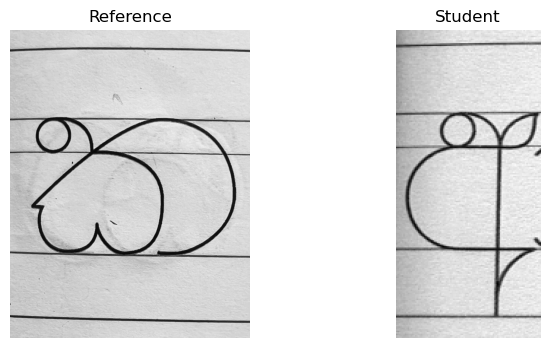

In [50]:
REFERENCE_PATH = r"reference_data/ක/base.png"   # your sample reference image
STUDENT_PATH   = r"student_data/sample1.png"   # student written image

ref_img = imread_unicode(REFERENCE_PATH)
stu_img = imread_unicode(STUDENT_PATH)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(ref_img, cmap="gray"); plt.title("Reference"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(stu_img, cmap="gray"); plt.title("Student"); plt.axis("off")
plt.show()

Binarization Utility

In [51]:
def binarize(img):
    _, binary = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    return cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)


5-LINE PAPER DETECTION (ROBUST)

In [52]:
def detect_horizontal_lines(binary):
    proj = np.sum(binary, axis=1)
    proj = proj / np.max(proj)

    strong = np.where(proj > 0.45)[0]
    weak   = np.where((proj > 0.25) & (proj <= 0.45))[0]

    def cluster(idx, gap=6):
        if len(idx) == 0:
            return []
        lines, curr = [], [idx[0]]
        for i in idx[1:]:
            if i - curr[-1] <= gap:
                curr.append(i)
            else:
                lines.append(int(np.mean(curr)))
                curr = [i]
        lines.append(int(np.mean(curr)))
        return lines

    strong_lines = cluster(strong)
    weak_lines   = cluster(weak)

    return strong_lines, weak_lines


Extract FULL SIGNATURE (USED FOR BOTH)

In [53]:
def extract_signature(img):
    binary = binarize(img)

    # Bounding box
    coords = cv2.findNonZero(binary)
    if coords is None:
        raise ValueError("No ink detected")

    x, y, w, h = cv2.boundingRect(coords)

    # Lines
    strong_lines, weak_lines = detect_horizontal_lines(binary)

    if len(strong_lines) < 3:
        raise ValueError("Not enough guide lines")

    # Support 3-line OR 5-line paper
    if len(strong_lines) >= 5:
        topline     = strong_lines[0]
        upper_mid   = strong_lines[1]
        midline     = strong_lines[2]
        lower_mid   = strong_lines[3]
        baseline    = strong_lines[4]
    else:
        topline, midline, baseline = strong_lines[:3]
        upper_mid = lower_mid = None

    return {
        "binary": binary,
        "bbox": (x, y, w, h),
        "letter_top": y,
        "letter_bottom": y + h,
        "topline": topline,
        "upper_mid": upper_mid,
        "midline": midline,
        "lower_mid": lower_mid,
        "baseline": baseline,
        "extra_lines": weak_lines
    }


RELATIVE ZONE PROFILE (FIXED LOGIC)

In [54]:
def relative_profile(sig):
    zone_height = sig["baseline"] - sig["midline"]

    top_ratio = (sig["midline"] - sig["letter_top"]) / zone_height
    bottom_ratio = (sig["letter_bottom"] - sig["midline"]) / zone_height

    # Clamp to [0, 1.5] to avoid math explosions
    top_ratio = np.clip(top_ratio, 0, 1.5)
    bottom_ratio = np.clip(bottom_ratio, 0, 1.5)

    return {
        "top_ratio": top_ratio,
        "bottom_ratio": bottom_ratio
    }


STROKE-SHAPE SIMILARITY (🔥 KEY ADDITION)

In [55]:
def shape_similarity(sig_a, sig_b):
    # Find contours
    cnts_a, _ = cv2.findContours(sig_a["binary"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts_b, _ = cv2.findContours(sig_b["binary"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not cnts_a or not cnts_b:
        return 1.0  # maximum difference

    # Take largest contour (the letter)
    cnt_a = max(cnts_a, key=cv2.contourArea)
    cnt_b = max(cnts_b, key=cv2.contourArea)

    # IMPORTANT: do NOT normalize manually
    return cv2.matchShapes(cnt_a, cnt_b, cv2.CONTOURS_MATCH_I1, 0)


FINAL SCORING (ZONE + SHAPE)

In [56]:
def final_score(stu_sig, ref_sig):
    # Relative profiles
    stu_prof = relative_profile(stu_sig)
    ref_prof = relative_profile(ref_sig)

    zone_diff = abs(stu_prof["top_ratio"] - ref_prof["top_ratio"]) + \
                abs(stu_prof["bottom_ratio"] - ref_prof["bottom_ratio"])

    zone_score = max(0, 100 - zone_diff * 80)

    # Shape similarity
    shape_diff = shape_similarity(stu_sig, ref_sig)
    shape_score = max(0, 100 - shape_diff * 300)

    # Extra helper line penalty
    penalty = 0
    for y in stu_sig["extra_lines"]:
        if stu_sig["letter_top"] <= y <= stu_sig["letter_bottom"]:
            penalty += 5

    final = int(0.6 * zone_score + 0.4 * shape_score - penalty)
    return max(0, min(100, final))


RUN EVERYTHING

In [57]:
ref_sig = extract_signature(ref_img)
stu_sig = extract_signature(stu_img)

score = final_score(stu_sig, ref_sig)
print("Final Alignment Score:", score)


Final Alignment Score: 3


VISUAL DEBUG (OPTIONAL BUT USEFUL)

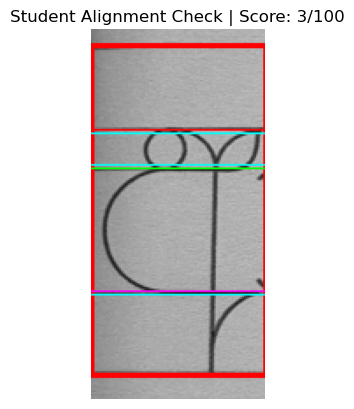

In [58]:
def visualize(img, sig, title, score):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    x, y, w, h = sig["bbox"]
    cv2.rectangle(vis, (x,y), (x+w,y+h), (255,0,0), 2)

    for k, c in [("topline",(255,0,0)),("midline",(0,255,0)),("baseline",(255,0,255))]:
        cv2.line(vis, (0, sig[k]), (img.shape[1], sig[k]), c, 1)

    for y in sig["extra_lines"]:
        cv2.line(vis, (0,y), (img.shape[1], y), (0,255,255), 1)

    plt.imshow(vis, cmap="gray")
    plt.title(f"{title} | Score: {score}/100")
    plt.axis("off")
    plt.show()

visualize(stu_img, stu_sig, "Student Alignment Check", score)
